# Paper 1 — Manuscript Figures (Executed, Outputs Embedded)

This notebook generates and displays the **10 currently-manuscript-used
figures produced from this codebase's Python/matplotlib plotting scripts**:
Figures 4 through 13.

**Three figures are intentionally excluded, not overlooked:**
- **Figure 1** (sub-basin delineation map) is a **GIS-generated map**
  (ArcGIS/QGIS, projected UTM Zone 13N, drawn from the watershed's GIS
  attribute table) — it is **not** produced by any Python/matplotlib
  script in this codebase, so it falls outside this notebook's own stated
  scope ("figures generated from Python/matplotlib code") exactly like
  Figures 2 and 3 below, even though an earlier draft of this notebook
  mistakenly included a placeholder for it (a training-loss-convergence
  plot that does not correspond to the manuscript's real Figure 1 at all
  — see the correction note in the next cell).
- **Figures 2 and 3** are the two conceptual diagrams (water/tracer-balance
  schematic and model-architecture diagram) — made separately, outside
  this codebase's plotting scripts.

**Why a notebook and not a script**: GitHub renders a `.ipynb` file's saved
cell outputs directly inline when someone clicks it in the repo — no one
needs to run anything to see the figures. This notebook has been executed
top to bottom and saved with its outputs embedded specifically for that
reason.

**No retraining anywhere** — every figure below is produced by loading
existing trained checkpoints already in this repo and running inference
only (or, for Figures 10–13, reading each checkpoint's already-computed
`metrics.json`/`predictions.npz` directly — no forward pass needed for
those four at all).

**Source scripts used** (current, corrected versions):
- `make_plots_final.py` — Figures 4, 5, 8 (flow partitioning, storage
  dynamics, baseflow-fraction validation against the Carroll et al. (2018)
  benchmark — citation fix already applied).
- `make_plots_investigation_trail.py` — Figures 6, 7 (unified low-storage
  evapoconcentration mechanism; PH_LT peak before/after the melt-lag fix).
- `make_plots_rfceiling.py` — Figure 9 (recharge-fraction ceiling,
  before/after).
- `make_plots_comparative.py` — Figures 10, 11 (3-way held-out NSE
  comparison; LSTM capacity ablation).
- `make_plots_multiseed.py` — Figure 12 (multi-seed robustness, NSE only
  — the pre-existing figure in this script; **not** the new KGE/PBIAS
  figure this script also contains, which does not correspond to any
  manuscript figure — KGE lives in the manuscript's Table 5, baseflow
  PBIAS in Table 2, not in a figure).
- `make_plots_splitcin_holdout.py` — Figure 13 (4-way held-out comparison
  adding the split-C_in variant).

This notebook lives in `pinn/` and imports directly from `data.py`,
`model.py`, `metrics.py`, and `style.py` in this same folder — the same
modules the `.py` scripts themselves use — so there is no risk of the
notebook's logic silently drifting from the corrected scripts over time.


## Correction note (this revision)

An earlier version of this notebook proposed a Figure 1/4–13 mapping that
was built **before** the current manuscript draft (`manuscript_draft_v1.docx`)
had been checked directly — it relied on a stale figure manifest and,
where that was insufficient, a reconstruction proposed without the source
document in hand. Checking that mapping against the manuscript's actual
captions found it wrong for **10 of the 11 slots** (only the storage-dynamics
figure coincidentally matched both number and content). This revision
replaces every mismatched figure and caption, and drops the earlier
notebook's invented "Figure 12" (multi-seed KGE/PBIAS) entirely, since no
such figure exists in the manuscript.

Two figures considered for removal from the codebase's figure set —
`09_storage_floor_diagnostic.png` and `10_ode_exactness_check.png` — were
checked directly against the manuscript's full text (not just the figure
list) before being left out of this notebook: neither "storage-floor
diagnostic" nor "ODE exactness" corresponds to any manuscript figure or
caption under any name, so their exclusion is confirmed correct, not an
oversight.


## Setup (shared by multiple figures below — not one of the 10 manuscript figures itself)

Imports, path configuration, and the one shared forward pass that Figures
4, 5, and 8 all reuse (they come from the same source script,
`make_plots_final.py`, which computes this once and reuses it across
figures rather than repeating the forward pass three times — this
notebook mirrors that). Figures 6, 7, and 9 load their own additional
checkpoints independently in their own cells, since each needs a
different combination of checkpoints. Figures 10–13 need no forward pass
at all — they read each checkpoint's already-computed `metrics.json`/
`predictions.npz` directly.


In [1]:
import os
import sys
import json

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

# This notebook lives in pinn/, as a sibling of data.py/model.py/metrics.py/
# style.py -- import them directly, exactly like every .py plotting script
# in this repo does, so this notebook can never silently drift from the
# corrected scripts (no reimplementation, no copy-paste of logic).
sys.path.insert(0, os.getcwd())
from data import load_dataset, SUBBASINS, UPSTREAM
from model import HydroPINN, SUB_IDX
from style import C, FONT, apply_base_style, savefig

# PROJECT_ROOT = repo root (parent of pinn/), matching the PROJECT_ROOT
# convention every .py script computes via dirname(dirname(__file__)) --
# notebooks have no __file__, so this assumes the standard layout (this
# notebook opened with pinn/ as the working directory, the normal case).
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "pinn" else os.getcwd()
DATA_DIR = f"{PROJECT_ROOT}/uploaded_data"

apply_base_style()
ORDER = SUBBASINS  # canonical sub-basin order: Rustlers, Copper, EAQ, Gothic_ME, PH_LT (outlet)


# Routes LOCAL per-node arrays [T, n_sub] through the watershed's confluence
# topology U(j) (Rustlers/Copper/EAQ are independent headwaters; EBC sums
# all three plus its own local drainage; PH_LT, the outlet, sums EBC plus
# its own local drainage -- see manuscript Figure 1's delineation). This is
# what converts a "locally generated" quantity into the "routed" quantity an
# actual downstream stream gauge would record -- the distinction the
# manuscript draws explicitly between Figure 4 (local) and Figure 8 (routed).
def route(local_dict):
    routed = {k: v.copy() for k, v in local_dict.items()}
    for b in ORDER:
        j = SUB_IDX[b]
        for u in UPSTREAM[b]:
            ui = SUB_IDX[u]
            for k in routed:
                routed[k][:, j] = routed[k][:, j] + routed[k][:, ui]
    return routed


# --- Shared forward pass for Figures 4, 5, 8 -------------------------------
# Checkpoint: results_meltlag_split -- the split-chloride-end-member (C_in,fast/
# C_in,gw) variant of the current RECOMMENDED checkpoint (melt-timing-lag-
# corrected, phase-partitioned P_e, C_f ceiling applied via the current
# model.py at inference -- not retrained with the ceiling, since that retrain
# was tested and found to be a net regression; see manuscript Section 3.9).
# This is the exact checkpoint manuscript Figure 5's caption names explicitly
# ("split-chloride-end-member variant shown").
SPLIT_DIR = f"{PROJECT_ROOT}/results_meltlag_split"
SINGLE_DIR = f"{PROJECT_ROOT}/results_meltlag_single"

d = load_dataset(DATA_DIR)
dates = d["dates"]
model = HydroPINN()
model.load_state_dict(torch.load(f"{SPLIT_DIR}/model.pt", map_location="cpu"))
model.eval()
precip = torch.tensor(d["pe_mm_day"])  # effective water input P_e = P_liquid + SM (phase-partitioned)
et = torch.tensor(d["et_mm_day"])
doy = torch.tensor(dates.dayofyear.values.astype(np.float32))
with torch.no_grad():
    out = model(precip, et, doy)

Sf = out["Sf"].numpy(); Ss = out["Ss"].numpy()          # fast/slow reservoir storage (mm)
Quf = out["Quf"].numpy(); Qf = out["Qf"].numpy(); Qs = out["Qs"].numpy()  # local discharge by pathway (mm/day)
area_cms = model.area_cms.numpy()  # per-node mm/day -> m^3/s conversion factor
Quf_vol, Qf_vol, Qs_vol = Quf * area_cms, Qf * area_cms, Qs * area_cms
routed = route({"Quf": Quf_vol.copy(), "Qf": Qf_vol.copy(), "Qs": Qs_vol.copy()})
Quf_tot, Qf_tot, Qs_tot = routed["Quf"], routed["Qf"], routed["Qs"]
Qtot_routed = Quf_tot + Qf_tot + Qs_tot

# Local (unrouted) fast-flow fraction -- Figure 4's quantity: what fraction
# of LOCALLY generated water leaves via the fast pathways (Quf+Qf) vs. slow.
fast_frac_local = (Quf + Qf) / np.clip(Quf + Qf + Qs, 1e-9, None)

# Routed baseflow fraction -- Figure 8's quantity: what an actual downstream
# gauge would record, after upstream contributions are summed through the
# network topology. Deliberately a SEPARATE quantity from fast_frac_local
# above, not a routed version of the same array -- the manuscript's Figure 4
# caption and Figure 8 caption both explicitly flag this local-vs-routed
# distinction as the reason day-to-day flicker in Figure 4 does not appear
# in Figure 8's time-averaged, routed view.
baseflow_frac_routed = Qs_tot / np.clip(Qtot_routed, 1e-9, None)


## Figure 4 — Locally generated flow, by pathway, and the resulting fast-flow fraction

Stacked local discharge components (ultra-fast, fast, slow) per sub-basin,
and the daily fast-flow fraction `(Q_uf+Q_f)/Q_loc` with a 7-day rolling
mean overlaid — the local, unrouted view whose day-to-day instability at
Rustlers/Copper/EAQ motivates the diagnostic investigation in Figures 6–7.


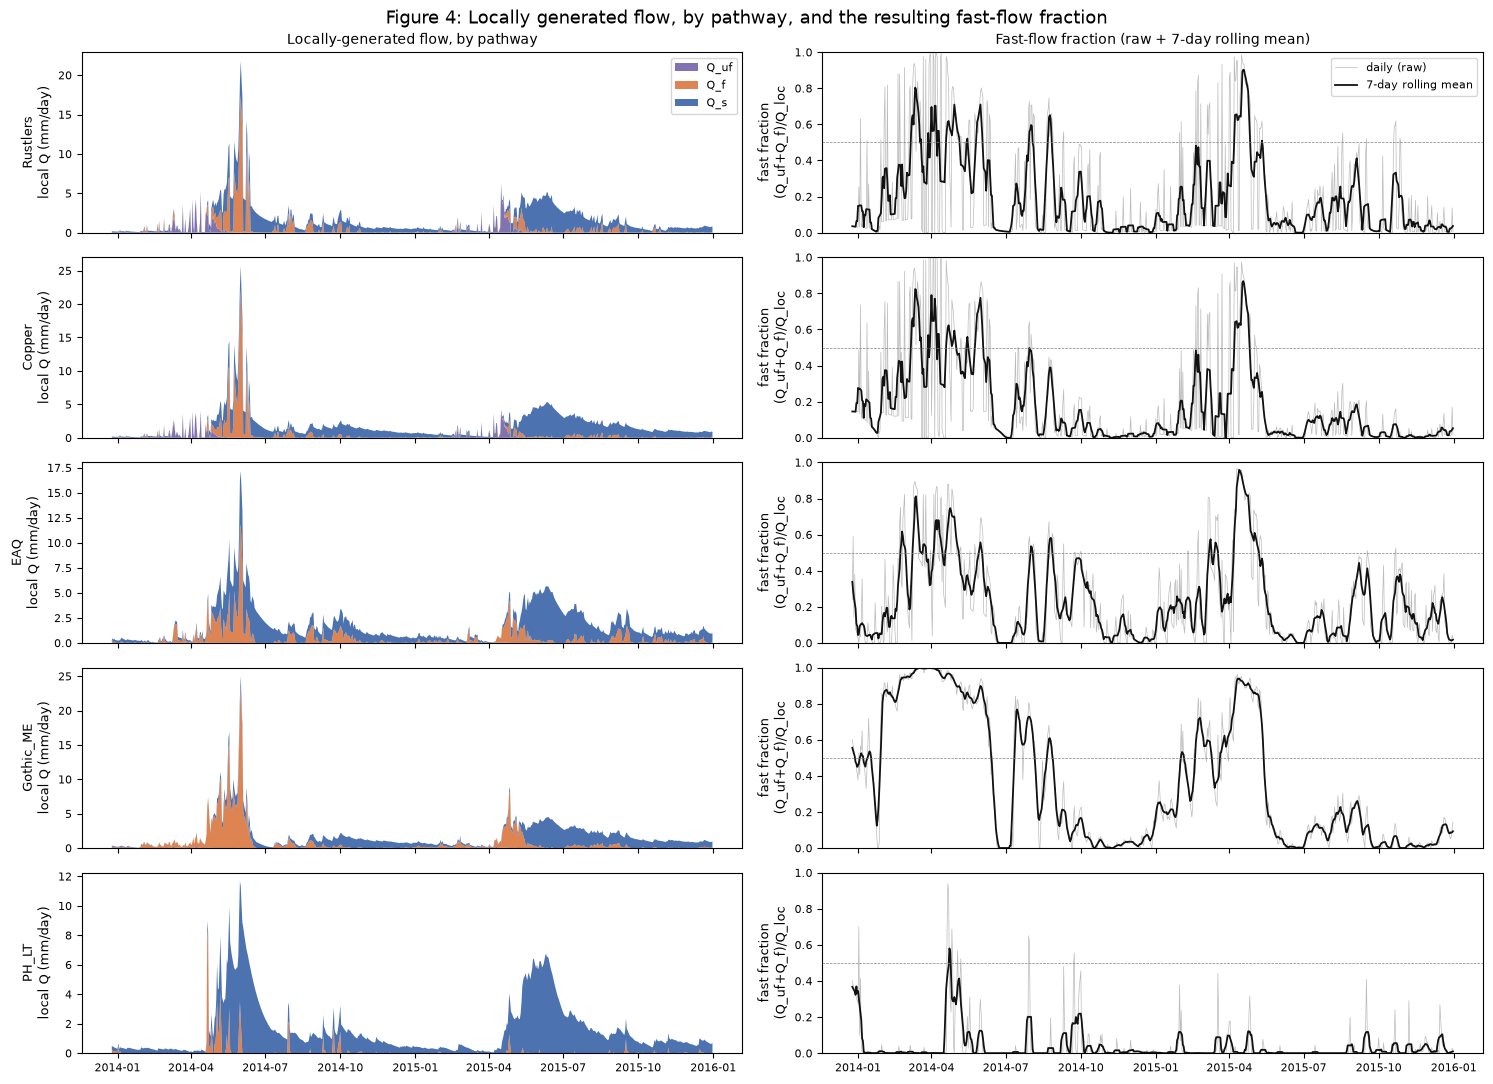

In [2]:
fig, axes = plt.subplots(len(ORDER), 2, figsize=(15, 2.2 * len(ORDER)), sharex="col")
for i, b in enumerate(ORDER):
    ax_stack, ax_frac = axes[i, 0], axes[i, 1]
    ax_stack.stackplot(dates, Quf[:, i], Qf[:, i], Qs[:, i],
                        colors=[C["Quf"], C["Qf"], C["Qs"]],
                        labels=["Q_uf", "Q_f", "Q_s"])
    ax_stack.set_ylabel(f"{b}\nlocal Q (mm/day)")

    # 7-day centered rolling mean over the raw (flickering) fast-fraction
    # signal: the partition network re-decides f_uf/f_f independently each
    # day with no smoothness penalty, so the raw daily series is visually
    # dominated by flicker that obscures the underlying seasonal pattern --
    # the rolling mean is a display aid only, not a different quantity.
    raw = pd.Series(fast_frac_local[:, i], index=dates)
    roll = raw.rolling(7, center=True, min_periods=1).mean()
    ax_frac.plot(raw.index, raw.values, color="#bbbbbb", lw=0.5, label="daily (raw)")
    ax_frac.plot(roll.index, roll.values, color="#111111", lw=1.3, label="7-day rolling mean")
    ax_frac.set_ylim(0, 1)
    ax_frac.set_ylabel("fast fraction\n(Q_uf+Q_f)/Q_loc")
    ax_frac.axhline(0.5, color="gray", lw=0.5, ls="--")
    if i == 0:
        ax_stack.legend(loc="upper right"); ax_stack.set_title("Locally-generated flow, by pathway")
        ax_frac.legend(loc="upper right"); ax_frac.set_title("Fast-flow fraction (raw + 7-day rolling mean)")
fig.suptitle("Figure 4: Locally generated flow, by pathway, and the resulting fast-flow fraction")
fig.tight_layout()
plt.show()


## Figure 5 — Learned fast- and slow-reservoir storage (log scale)

`S_f` (blue) and `S_s` (orange) over the training period, log scale, for
each sub-basin, under the final recommended (split-C_in) configuration.


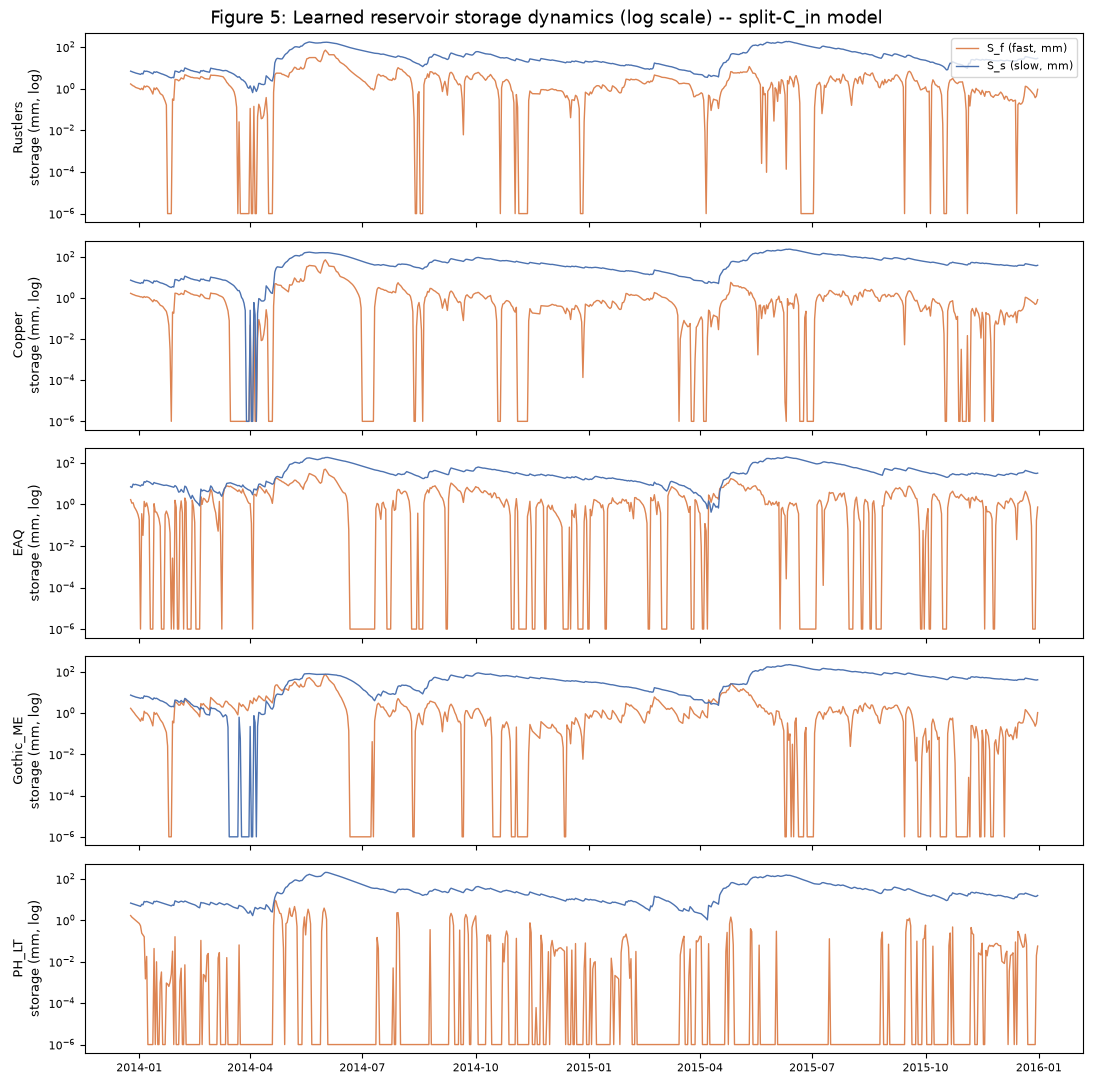

In [3]:
fig, axes = plt.subplots(len(ORDER), 1, figsize=(11, 2.2 * len(ORDER)), sharex=True)
for i, b in enumerate(ORDER):
    ax = axes[i]
    # Both storages are numerically floored at 1e-6 mm as a computational
    # safeguard (prevents log(0)/division-by-zero elsewhere in the model),
    # not a physical zero -- plotted from that floor rather than clipped to
    # something larger, so the floor-dwelling behavior itself stays visible.
    ax.plot(dates, np.clip(Sf[:, i], 1e-6, None), color=C["Sf"], lw=1.0, label="S_f (fast, mm)")
    ax.plot(dates, np.clip(Ss[:, i], 1e-6, None), color=C["Ss"], lw=1.0, label="S_s (slow, mm)")
    # Log scale, not linear: S_s would otherwise be visually flattened
    # against S_f's much larger range.
    ax.set_yscale("log")
    ax.set_ylabel(f"{b}\nstorage (mm, log)")
    if i == 0:
        ax.legend(loc="upper right")
fig.suptitle("Figure 5: Learned reservoir storage dynamics (log scale) -- split-C_in model")
fig.tight_layout()
plt.show()


## Figure 6 — Slow-reservoir storage, tracer mass, and concentration on worst chloride-residual days

At Rustlers Gulch, Copper Creek, and EAQ: `S_s`, `M_s` (tracer mass,
`C_s * S_s`), and `C_s` (`M_s/S_s`), each expressed as the ratio of its
median value on that gauge's worst chloride-residual days to its own
overall median — showing that concentration spikes arise from a shrinking
storage denominator, not from any change in tracer mass.


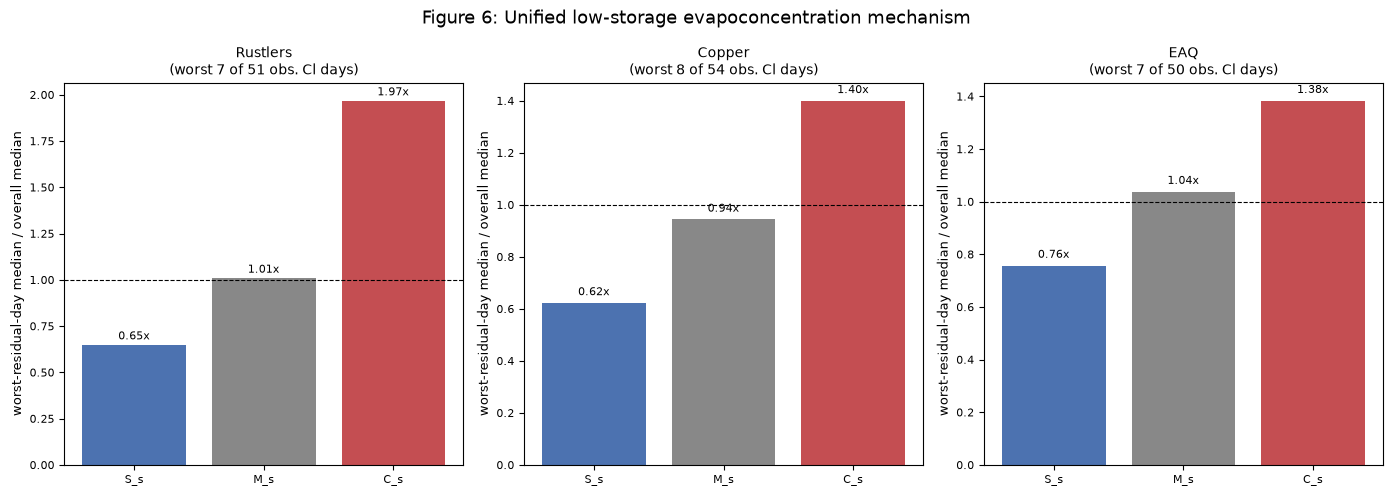

In [4]:
# Independent forward pass (not the Setup cell's split-C_in model): this
# figure uses results_meltlag_single (split_cin=False) specifically, since
# it is documenting a mechanism (evapoconcentration via storage depletion)
# that is a property of the reservoir architecture shared by both variants,
# and FINDINGS.md's original diagnostic for this mechanism was run against
# the single-C_in checkpoint.
CKPT_SINGLE = f"{PROJECT_ROOT}/results_meltlag_single"
d6 = load_dataset(DATA_DIR)
dates6 = d6["dates"]
model6 = HydroPINN(split_cin=False)
model6.load_state_dict(torch.load(f"{CKPT_SINGLE}/model.pt", map_location="cpu"))
model6.eval()
with torch.no_grad():
    out6 = model6(torch.tensor(d6["pe_mm_day"]), torch.tensor(d6["et_mm_day"]),
                  torch.tensor(dates6.dayofyear.values.astype(np.float32)))
cl_obs_all = d6["cl_obs_mgL"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
mech_gauges = ["Rustlers", "Copper", "EAQ"]
for ax, b in zip(axes, mech_gauges):
    j = SUB_IDX[b]
    Ss6 = out6["Ss"].numpy()[:, j]
    Cs6 = out6["Cs"].numpy()[:, j]
    Ms6 = Cs6 * Ss6  # tracer mass reconstructed as concentration x storage
    Quf6 = out6["Quf"].numpy(); Qf6 = out6["Qf"].numpy(); Qs6 = out6["Qs"].numpy()
    area_cms6 = model6.area_cms.numpy()
    routed6 = route({"Quf": Quf6 * area_cms6, "Qf": Qf6 * area_cms6, "Qs": Qs6 * area_cms6})
    Ctot6 = out6["Ctot"].numpy()[:, j]
    cl_obs6 = cl_obs_all[:, j]
    mask6 = np.isfinite(cl_obs6)
    resid6 = np.abs(Ctot6 - cl_obs6)
    idxs6 = np.where(mask6)[0]
    # "Worst" days = top 15% by |simulated - observed chloride| residual
    # (or the worst 5 if 15% would be fewer than 5) -- these are the days
    # the mechanism below is meant to explain.
    top_n = idxs6[np.argsort(-resid6[idxs6])[: max(5, int(0.15 * len(idxs6)))]]

    # Ratios use the MEDIAN, not the mean, deliberately: C_s has no ceiling
    # anywhere in the current code (unlike C_f, which was given one) and
    # spikes to 3.7-3.9 million mg/L on a handful of days at Copper/
    # Gothic_ME when S_s crashes to its literal eps=1e-6 numerical floor.
    # This is a known, documented structural issue (not a bug introduced
    # here) -- see manuscript Figure 6's caption and Section 3's storage-
    # floor discussion. The mean would be dominated by those rare extreme
    # days; the median represents the great majority of the record.
    ratios = [
        np.median(Ss6[top_n]) / np.median(Ss6),
        np.median(Ms6[top_n]) / np.median(Ms6),
        np.median(Cs6[top_n]) / np.median(Cs6),
    ]
    bars = ax.bar(["S_s", "M_s", "C_s"], ratios, color=[C["Ss"], "#888888", C["highlight"]])
    ax.axhline(1.0, color="black", lw=0.8, ls="--")
    ax.set_ylabel("worst-residual-day median / overall median")
    ax.set_title(f"{b}\n(worst {len(top_n)} of {mask6.sum()} obs. Cl days)", fontsize=FONT["title"])
    for rect, v in zip(bars, ratios):
        ax.text(rect.get_x() + rect.get_width() / 2, v + 0.03, f"{v:.2f}x", ha="center", fontsize=FONT["annot"])
fig.suptitle("Figure 6: Unified low-storage evapoconcentration mechanism")
fig.tight_layout()
plt.show()


## Figure 7 — PH_LT peak: before vs. after the melt-timing-lag correction

Simulated vs. observed discharge at the watershed outlet (PH_LT) during the
2014 and 2015 snowmelt peaks, comparing the configuration before (no
melt-timing correction) and after (10-day melt-timing-lag correction, the
current recommended configuration) the fix described in manuscript Section
3.6.


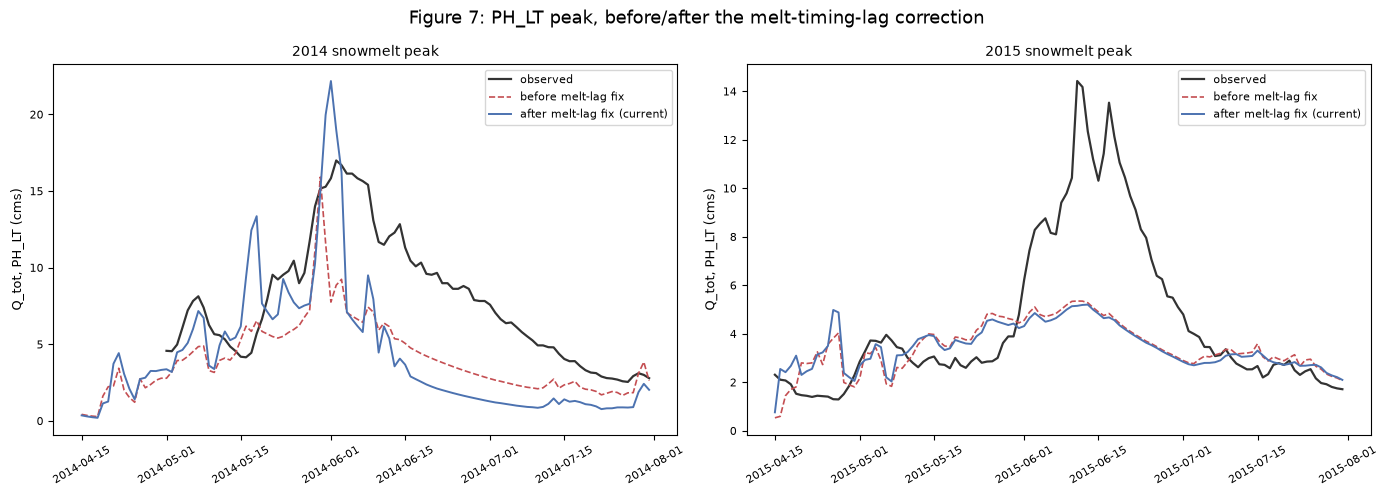

In [5]:
# Two independent checkpoints, loaded specifically to isolate ONE change
# (the melt-timing-lag correction) -- "after" is the current recommended
# checkpoint (results_meltlag_single); "before" (results_phasepartition_single)
# is the immediately-preceding round, phase-partitioned P_e but without the
# melt-lag fix, i.e. the exact prior state the fix was applied to.
def load_forward7(ckpt_dir, split_cin, pe_key="pe_mm_day"):
    dd = load_dataset(DATA_DIR)
    ddates = dd["dates"]
    pe = torch.tensor(dd[pe_key]); et7 = torch.tensor(dd["et_mm_day"])
    doy7 = torch.tensor(ddates.dayofyear.values.astype(np.float32))
    m = HydroPINN(split_cin=split_cin)
    m.load_state_dict(torch.load(f"{ckpt_dir}/model.pt", map_location="cpu"))
    m.eval()
    with torch.no_grad():
        o = m(pe, et7, doy7)
    return dd, ddates, m, o

d_after, dates7, model_after, out_after = load_forward7(f"{PROJECT_ROOT}/results_meltlag_single", split_cin=False)
d_before, _, model_before, out_before = load_forward7(f"{PROJECT_ROOT}/results_phasepartition_single", split_cin=False)

def routed_qtot(m, o):
    Quf7 = o["Quf"].numpy(); Qf7 = o["Qf"].numpy(); Qs7 = o["Qs"].numpy()
    ac7 = m.area_cms.numpy()
    r7 = route({"Quf": Quf7 * ac7, "Qf": Qf7 * ac7, "Qs": Qs7 * ac7})
    return r7["Quf"] + r7["Qf"] + r7["Qs"]

Qtot_after = routed_qtot(model_after, out_after)
Qtot_before = routed_qtot(model_before, out_before)
j_ph = SUB_IDX["PH_LT"]
qobs = pd.read_csv(f"{DATA_DIR}/discharge_5subbasins_daily_long.csv")
qobs["date"] = pd.to_datetime(qobs["date"])
qobs_phlt = qobs[qobs["sub_basin"] == "PH_LT"].set_index("date")["Q_cms"].reindex(dates7)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (start, end), yr in zip(axes, [("2014-04-15", "2014-07-31"), ("2015-04-15", "2015-07-31")], ["2014", "2015"]):
    mask7 = (dates7 >= start) & (dates7 <= end)
    ax.plot(dates7[mask7], qobs_phlt.values[mask7], color=C["obs"], lw=1.6, label="observed")
    ax.plot(dates7[mask7], Qtot_before[mask7, j_ph], color=C["highlight"], lw=1.2, ls="--", label="before melt-lag fix")
    ax.plot(dates7[mask7], Qtot_after[mask7, j_ph], color=C["single"], lw=1.4, label="after melt-lag fix (current)")
    ax.set_ylabel("Q_tot, PH_LT (cms)")
    ax.set_title(f"{yr} snowmelt peak", fontsize=FONT["title"])
    ax.legend(fontsize=FONT["legend"])
    ax.tick_params(axis="x", rotation=30)
# Peak timing improves in both years (11-13 days early -> within ~2 days),
# but magnitude/shape do NOT both improve: 2014 overshoots (1.31x observed),
# 2015 still substantially undershoots (0.36x observed) -- attributed in
# the manuscript (Section 3.6) to the single-station SNOTEL proxy's
# inability to supply the correct total melt mass for this sub-basin, a
# known, documented data limitation, not an open bug or a fitting failure.
fig.suptitle("Figure 7: PH_LT peak, before/after the melt-timing-lag correction")
fig.tight_layout()
plt.show()


## Figure 8 — Routed baseflow fraction vs. the Carroll et al. (2018) benchmark

`Q_s,tot/Q_tot` — slow-reservoir discharge as a fraction of total discharge
after routing through the network topology (the quantity an actual stream
gauge would record) — against the 12–33% (mean annual) / 17–50%
(baseflow-period, Dec–Mar) benchmark band from Carroll et al. (2018).


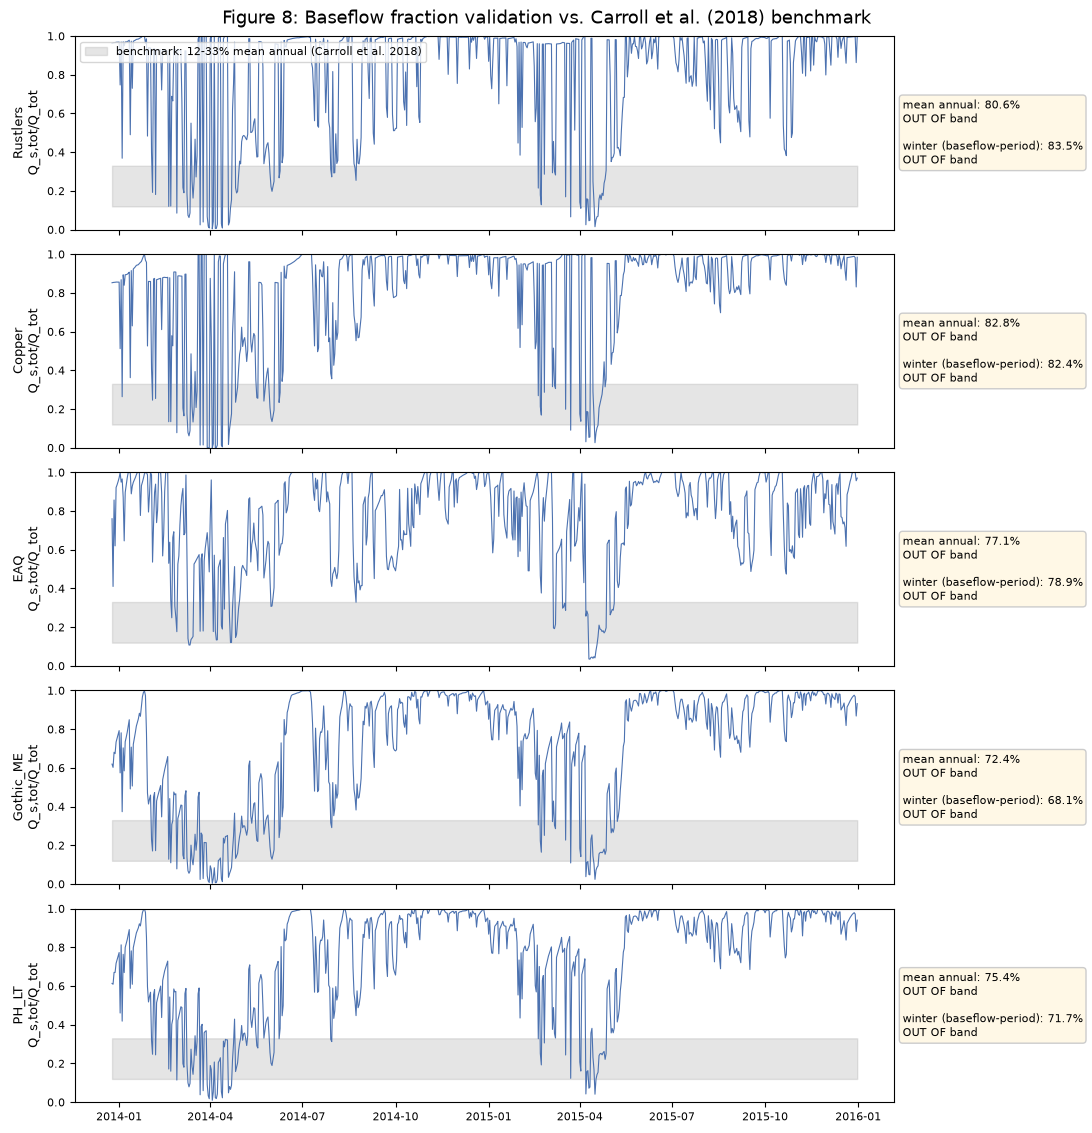

Rustlers: 80.6% annual (OUT OF band), 83.5% winter (OUT OF band)
Copper: 82.8% annual (OUT OF band), 82.4% winter (OUT OF band)
EAQ: 77.1% annual (OUT OF band), 78.9% winter (OUT OF band)
Gothic_ME: 72.4% annual (OUT OF band), 68.1% winter (OUT OF band)
PH_LT: 75.4% annual (OUT OF band), 71.7% winter (OUT OF band)


In [6]:
CARROLL_ANNUAL = (0.12, 0.33)
CARROLL_BASEFLOW_PERIOD = (0.17, 0.50)
# Baseflow period = winter (Dec-Mar): snow-covered, no active melt input,
# flow dominated by recession -- a standard definition for a snowmelt-
# dominated catchment, and the same definition used throughout this project.
winter_mask = dates.month.isin([12, 1, 2, 3])

fig, axes = plt.subplots(len(ORDER), 1, figsize=(11, 2.3 * len(ORDER)), sharex=True)
summary_rows = []
for i, b in enumerate(ORDER):
    ax = axes[i]
    frac = baseflow_frac_routed[:, i]
    ax.fill_between(dates, CARROLL_ANNUAL[0], CARROLL_ANNUAL[1], color=C["benchmark"], alpha=0.25,
                     label="benchmark: 12-33% mean annual (Carroll et al. 2018)")
    ax.plot(dates, frac, color=C["Ss"], lw=0.8)
    ax.set_ylim(0, 1)
    ax.set_ylabel(f"{b}\nQ_s,tot/Q_tot")

    mean_annual = float(np.nanmean(frac))
    mean_baseflow_period = float(np.nanmean(frac[winter_mask]))
    in_annual_band = CARROLL_ANNUAL[0] <= mean_annual <= CARROLL_ANNUAL[1]
    in_bfperiod_band = CARROLL_BASEFLOW_PERIOD[0] <= mean_baseflow_period <= CARROLL_BASEFLOW_PERIOD[1]
    ax.text(1.01, 0.5,
            f"mean annual: {mean_annual:.1%}\n{'IN' if in_annual_band else 'OUT OF'} band\n\n"
            f"winter (baseflow-period): {mean_baseflow_period:.1%}\n{'IN' if in_bfperiod_band else 'OUT OF'} band",
            transform=ax.transAxes, va="center", fontsize=FONT["annot"],
            bbox=dict(boxstyle="round", fc="#fff8e6" if not in_annual_band else "#eaffea", ec="#ccc"))
    summary_rows.append((b, mean_annual, in_annual_band, mean_baseflow_period, in_bfperiod_band))
    if i == 0:
        ax.legend(loc="upper left", fontsize=FONT["legend"])
# All five gauges sit ABOVE this benchmark band on both the annual and
# winter-period average (manuscript Section 3.8.1) -- this is expected to
# print "OUT OF band" at every gauge below; that is the reported finding,
# not a fitting failure to be corrected.
fig.suptitle("Figure 8: Baseflow fraction validation vs. Carroll et al. (2018) benchmark")
fig.tight_layout()
plt.show()
for b, ma, ia, mb, ib in summary_rows:
    print(f"{b}: {ma:.1%} annual ({'in' if ia else 'OUT OF'} band), {mb:.1%} winter ({'in' if ib else 'OUT OF'} band)")


## Figure 9 — Baseflow fraction before/after the recharge-fraction ceiling constraint

Mean annual baseflow fraction before (freely-learned recharge fraction) and
after (soft ceiling, target 0.3) the constraint described in manuscript
Section 3.8.2, for both the single- and split-end-member variants.


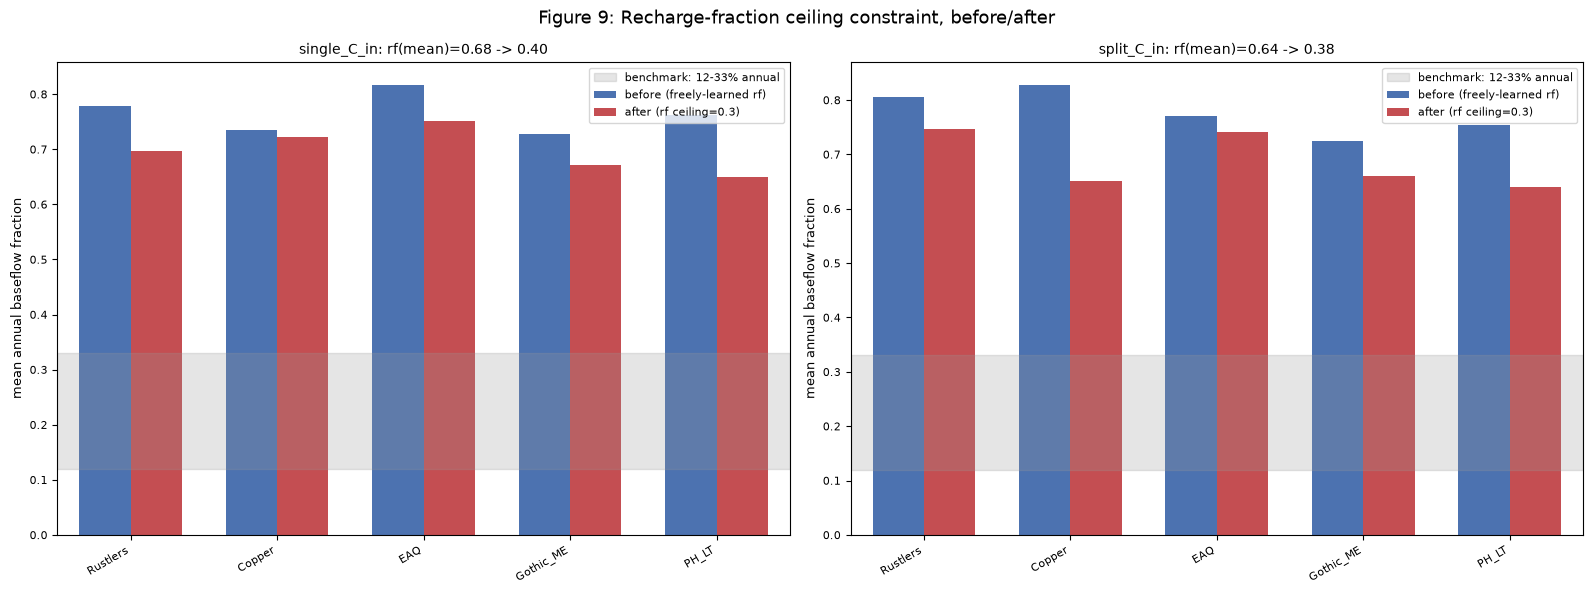

In [7]:
CARROLL_ANNUAL = (0.12, 0.33)

def load_forward9(ckpt_dir, split_cin):
    dd = load_dataset(DATA_DIR)
    ddates = dd["dates"]
    pe = torch.tensor(dd["pe_mm_day"]); et9 = torch.tensor(dd["et_mm_day"])
    doy9 = torch.tensor(ddates.dayofyear.values.astype(np.float32))
    m = HydroPINN(split_cin=split_cin)
    m.load_state_dict(torch.load(f"{ckpt_dir}/model.pt", map_location="cpu"))
    m.eval()
    with torch.no_grad():
        o = m(pe, et9, doy9)
    return dd, ddates, m, o

def baseflow_frac9(o, m):
    Quf9 = o["Quf"].numpy(); Qf9 = o["Qf"].numpy(); Qs9 = o["Qs"].numpy()
    ac9 = m.area_cms.numpy()
    r9 = route({"Quf": Quf9 * ac9, "Qf": Qf9 * ac9, "Qs": Qs9 * ac9})
    tot9 = r9["Quf"] + r9["Qf"] + r9["Qs"]
    return r9["Qs"] / np.clip(tot9, 1e-9, None)

# BEFORE = the current recommended checkpoint (freely-learned recharge
# fraction). AFTER = the identical training configuration PLUS
# --rf-weight 100.0 --rf-ceiling 0.3 (a soft penalty, calibrated the same
# way as the storage-barrier term) -- an isolated before/after comparison
# of exactly one change, per variant.
results9 = {}
for variant, split_cin in [("single", False), ("split", True)]:
    d_b, dates_b, model_b, out_b = load_forward9(f"{PROJECT_ROOT}/results_meltlag_{variant}", split_cin)
    d_a, dates_a, model_a, out_a = load_forward9(f"{PROJECT_ROOT}/results_rfceiling_{variant}", split_cin)
    bf_before = baseflow_frac9(out_b, model_b)
    bf_after = baseflow_frac9(out_a, model_a)
    rows = [(b, float(np.nanmean(bf_before[:, i])), float(np.nanmean(bf_after[:, i]))) for i, b in enumerate(ORDER)]
    # Mean recharge fraction = 1 - f_f (fraction of effective water input
    # NOT routed to the fast pathway) -- reported here as a scalar summary
    # of the constraint's direct effect, separate from its downstream
    # effect on baseflow fraction shown in the bars.
    rf_before = float((1.0 - out_b["f_f"]).mean().item())
    rf_after = float((1.0 - out_a["f_f"]).mean().item())
    results9[variant] = {"rows": rows, "rf_before": rf_before, "rf_after": rf_after}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(ORDER))
width = 0.35
for ax, variant in zip(axes, ["single", "split"]):
    rows = results9[variant]["rows"]
    ax.bar(x - width / 2, [r[1] for r in rows], width, label="before (freely-learned rf)", color=C["single"])
    ax.bar(x + width / 2, [r[2] for r in rows], width, label="after (rf ceiling=0.3)", color=C["highlight"])
    ax.fill_between([-0.5, len(ORDER) - 0.5], CARROLL_ANNUAL[0], CARROLL_ANNUAL[1], color=C["benchmark"], alpha=0.25, label="benchmark: 12-33% annual")
    ax.set_xlim(-0.5, len(ORDER) - 0.5)
    ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
    ax.set_ylabel("mean annual baseflow fraction")
    ax.set_title(f"{variant}_C_in: rf(mean)={results9[variant]['rf_before']:.2f} -> {results9[variant]['rf_after']:.2f}")
    ax.legend(fontsize=FONT["legend"])
# Expected result (manuscript Section 3.8.2): baseflow fraction falls at
# EVERY gauge in both variants but remains well above the benchmark band
# throughout -- the constraint moves the model in the right direction
# without fully closing the gap; this is the reported finding, not a
# partial failure of the plotting code.
fig.suptitle("Figure 9: Recharge-fraction ceiling constraint, before/after")
fig.tight_layout()
plt.show()


## Figure 10 — Held-out NSE: tracer-informed PINN vs. hydrology-only PINN vs. LSTM

Discharge NSE (left) and chloride NSE (right), all three models, computed
only on each gauge's held-out test-split days (fixed 80/20 split, seed=42,
identical across all three models — none ever trained on these days).


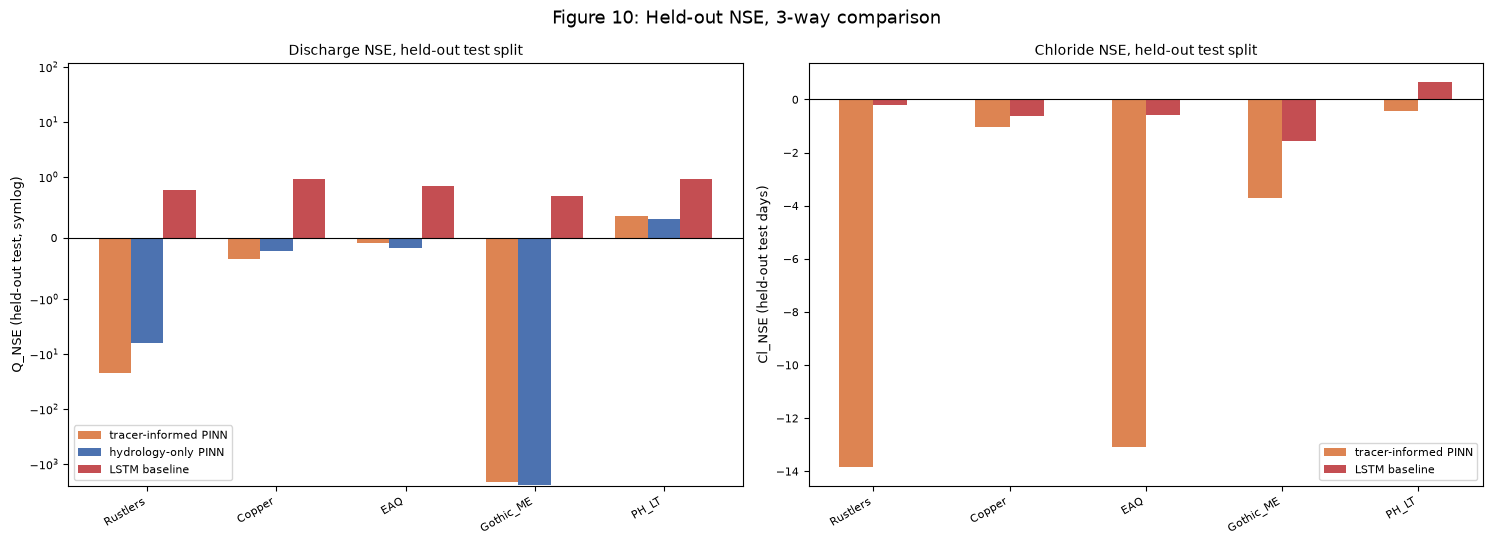

In [8]:
# No forward pass needed here at all -- unlike Figures 4-9, this figure
# reads each checkpoint's Q_NSE_test/Cl_NSE_test directly from its own
# already-computed metrics.json, exactly as make_plots_comparative.py does
# (the held-out split was applied once, at TRAINING time, by
# train_holdout.py -- this cell only reads the result).
TRACER_DIR = f"{PROJECT_ROOT}/results_comparative_tracer_single"
HYDRO_DIR = f"{PROJECT_ROOT}/results_comparative_hydro_only"
LSTM_DIR = f"{PROJECT_ROOT}/results_comparative_lstm"
with open(f"{TRACER_DIR}/metrics.json") as f:
    tracer_info = json.load(f)
with open(f"{HYDRO_DIR}/metrics.json") as f:
    hydro_info = json.load(f)
with open(f"{LSTM_DIR}/metrics.json") as f:
    lstm_info = json.load(f)

x = np.arange(len(ORDER))
width = 0.25
q_tracer = [tracer_info["metrics"][b]["Q_NSE_test"] for b in ORDER]
q_hydro = [hydro_info["metrics"][b]["Q_NSE_test"] for b in ORDER]
q_lstm = [lstm_info["metrics"][b]["Q_NSE_test"] for b in ORDER]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.bar(x - width, q_tracer, width, label="tracer-informed PINN", color=C["split"])
ax.bar(x, q_hydro, width, label="hydrology-only PINN", color=C["single"])
ax.bar(x + width, q_lstm, width, label="LSTM baseline", color=C["highlight"])
ax.axhline(0, color="black", lw=0.8)
# Symlog, not linear: Gothic_ME's discharge NSE (order -2,000) is the same
# pre-existing, structural issue documented in the manuscript (Section 3.7,
# small/near-zero observed discharge at that gauge) -- on a linear axis it
# would compress the other 4 gauges' bars to an indistinguishable line at 0.
ax.set_yscale("symlog", linthresh=1.0)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
ax.set_ylabel("Q_NSE (held-out test, symlog)")
ax.set_title("Discharge NSE, held-out test split")
ax.legend(fontsize=FONT["legend"], loc="lower left")

# Hydrology-only PINN has NO trained chloride output when cl_weight=0
# (Cin_fast/Cin_gw never receive gradient) -- omitted from the right panel
# entirely rather than shown with an untrained, meaningless value.
cl_tracer = [tracer_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
cl_lstm = [lstm_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
ax = axes[1]
ax.bar(x - width / 2, cl_tracer, width, label="tracer-informed PINN", color=C["split"])
ax.bar(x + width / 2, cl_lstm, width, label="LSTM baseline", color=C["highlight"])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
ax.set_ylabel("Cl_NSE (held-out test days)")
ax.set_title("Chloride NSE, held-out test split")
ax.legend(fontsize=FONT["legend"])
fig.suptitle("Figure 10: Held-out NSE, 3-way comparison")
fig.tight_layout()
plt.show()


## Figure 11 — LSTM capacity ablation (held-out chloride NSE)

Held-out chloride NSE for the LSTM baseline at two network capacities
(hidden=64, 20,618 params vs. hidden=16, 2,090 params), testing whether the
chloride held-out collapse at 4 of 5 gauges reflects model size or data
scarcity.


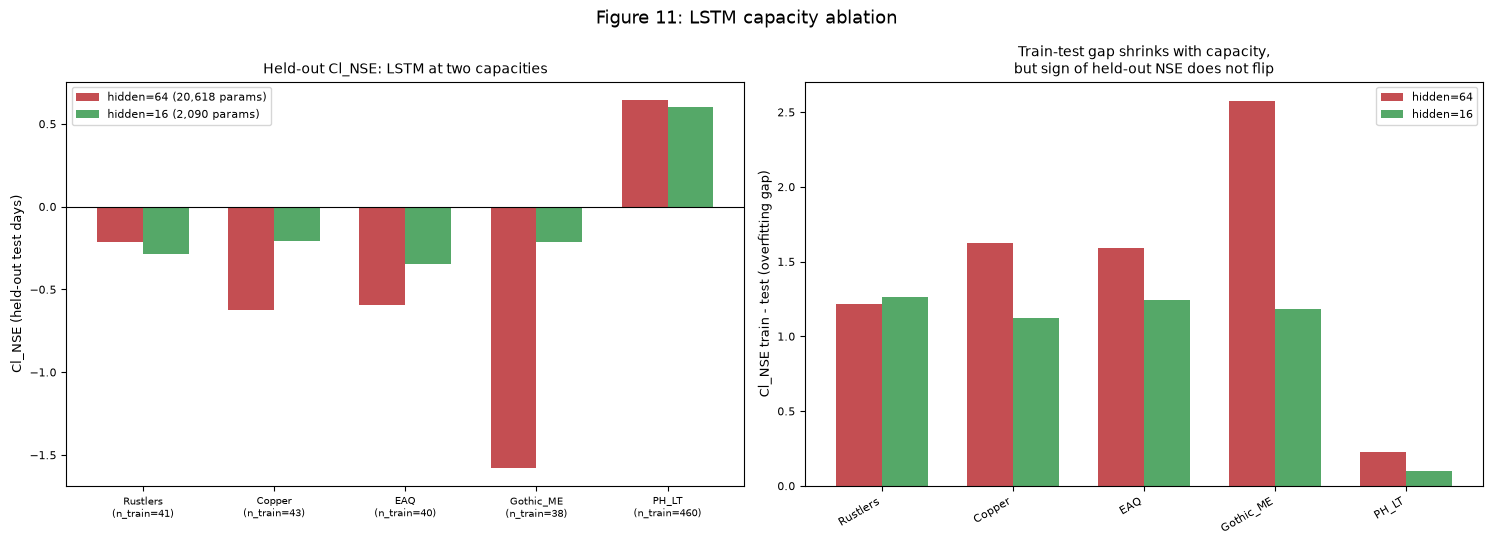

In [9]:
LSTM_SMALL_DIR = f"{PROJECT_ROOT}/results_comparative_lstm_small"
with open(f"{LSTM_SMALL_DIR}/metrics.json") as f:
    lstm_small_info = json.load(f)

cl_test_64 = [lstm_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
cl_test_16 = [lstm_small_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
gap_64 = [lstm_info["metrics"][b]["Cl_NSE_train"] - lstm_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
gap_16 = [lstm_small_info["metrics"][b]["Cl_NSE_train"] - lstm_small_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
# n_Clobs_train printed per gauge below: 38-43 at four gauges vs. 460 at
# PH_LT -- the sparsity contrast this ablation is testing against.
n_cl_train = [tracer_info["metrics"][b]["n_Clobs_train"] for b in ORDER]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
width = 0.35
ax = axes[0]
ax.bar(x - width / 2, cl_test_64, width, label="hidden=64 (20,618 params)", color=C["highlight"])
ax.bar(x + width / 2, cl_test_16, width, label="hidden=16 (2,090 params)", color=C["Cin_fast"])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels([f"{b}\n(n_train={n})" for b, n in zip(ORDER, n_cl_train)], rotation=0, fontsize=FONT["tick"] - 1)
ax.set_ylabel("Cl_NSE (held-out test days)")
ax.set_title("Held-out Cl_NSE: LSTM at two capacities")
ax.legend(fontsize=FONT["legend"])

ax = axes[1]
ax.bar(x - width / 2, gap_64, width, label="hidden=64", color=C["highlight"])
ax.bar(x + width / 2, gap_16, width, label="hidden=16", color=C["Cin_fast"])
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
ax.set_ylabel("Cl_NSE train - test (overfitting gap)")
ax.set_title("Train-test gap shrinks with capacity,\nbut sign of held-out NSE does not flip")
ax.legend(fontsize=FONT["legend"])
# Expected result: held-out Cl_NSE stays negative at all 4 sparse-Cl gauges
# at BOTH capacities -- a 10x capacity reduction does not change the
# qualitative outcome, indicating the collapse reflects data scarcity
# (38-43 obs) rather than this LSTM configuration being oversized.
fig.suptitle("Figure 11: LSTM capacity ablation")
fig.tight_layout()
plt.show()


## Figure 12 — Multi-seed robustness of the 3-way held-out comparison

Discharge NSE (top) and chloride NSE (bottom), mean across seeds with error
bars spanning the full observed min–max range (tracer-informed and
hydrology-only PINN, n=3 seeds each; LSTM baseline, n=5 seeds).


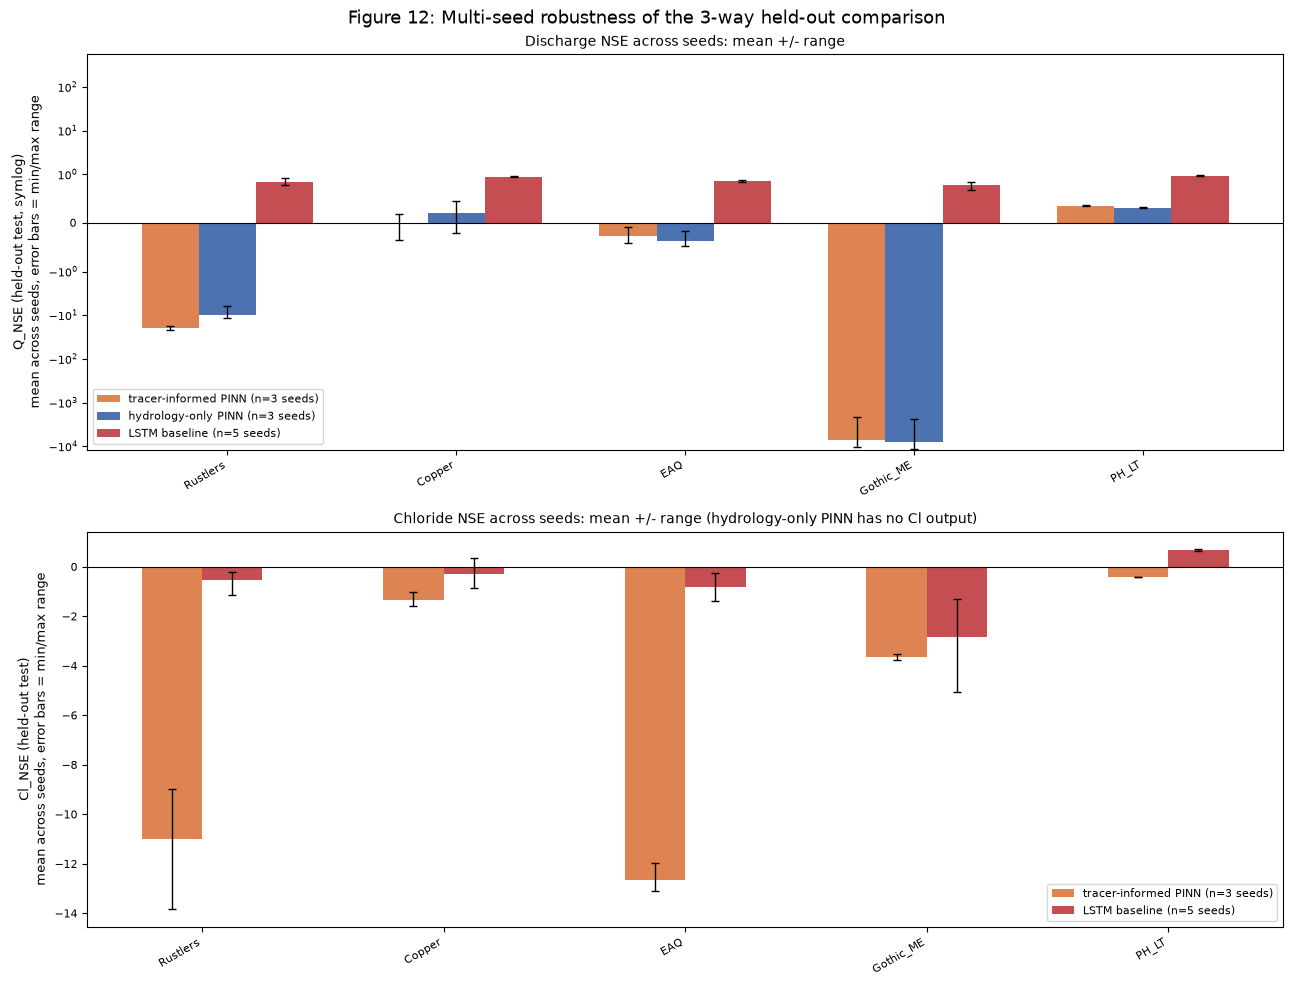

In [10]:
LSTM_SEEDS = [0, 1, 2, 3, 4]
PINN_SEEDS = [0, 1, 2]  # fewer than the LSTM's 5 -- a disclosed, compute-driven
# scope reduction (each additional PINN seed costs ~34 min on this
# environment's CPUs vs. ~1 min for an LSTM seed); see manuscript Section
# 3.10.1 and FINDINGS.md for the full accounting.

LSTM_DIRS = {0: f"{PROJECT_ROOT}/results_comparative_lstm"}
LSTM_DIRS.update({s: f"{PROJECT_ROOT}/results_comparative_lstm_seed{s}" for s in [1, 2, 3, 4]})
TRACER_DIRS = {0: f"{PROJECT_ROOT}/results_comparative_tracer_single"}
TRACER_DIRS.update({s: f"{PROJECT_ROOT}/results_comparative_tracer_single_seed{s}" for s in [1, 2]})
HYDRO_DIRS = {0: f"{PROJECT_ROOT}/results_comparative_hydro_only"}
HYDRO_DIRS.update({s: f"{PROJECT_ROOT}/results_comparative_hydro_only_seed{s}" for s in [1, 2]})

def load_metric_across_seeds(dirs, seeds, gauge, key):
    vals = []
    for s in seeds:
        with open(f"{dirs[s]}/metrics.json") as f:
            m = json.load(f)["metrics"]
        v = m[gauge][key]
        if v is not None:
            vals.append(v)
    return np.array(vals)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
ax = axes[0]
width = 0.25
for offset, (label, dirs, seeds, color) in enumerate([
    ("tracer-informed PINN", TRACER_DIRS, PINN_SEEDS, C["split"]),
    ("hydrology-only PINN", HYDRO_DIRS, PINN_SEEDS, C["single"]),
    ("LSTM baseline", LSTM_DIRS, LSTM_SEEDS, C["highlight"]),
]):
    means, los, his = [], [], []
    for b in ORDER:
        vals = load_metric_across_seeds(dirs, seeds, b, "Q_NSE_test")
        means.append(vals.mean())
        los.append(vals.mean() - vals.min())
        his.append(vals.max() - vals.mean())
    xpos = x + (offset - 1) * width
    ax.bar(xpos, means, width, label=f"{label} (n={len(seeds)} seeds)", color=color)
    # Error bars = full observed min/max range, NOT std or a confidence
    # interval -- with only 3-5 seeds, a std/CI would imply a distributional
    # assumption this sample size can't support; min/max shows exactly what
    # was observed, no more.
    ax.errorbar(xpos, means, yerr=[los, his], fmt="none", ecolor="black", elinewidth=1.0, capsize=3)
ax.axhline(0, color="black", lw=0.8)
ax.set_yscale("symlog", linthresh=1.0)  # same Gothic_ME rationale as Figure 10
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
ax.set_ylabel("Q_NSE (held-out test, symlog)\nmean across seeds, error bars = min/max range")
ax.set_title("Discharge NSE across seeds: mean +/- range")
ax.legend(fontsize=FONT["legend"], loc="lower left")

ax = axes[1]
for offset, (label, dirs, seeds, color) in enumerate([
    ("tracer-informed PINN", TRACER_DIRS, PINN_SEEDS, C["split"]),
    ("LSTM baseline", LSTM_DIRS, LSTM_SEEDS, C["highlight"]),
]):
    means, los, his = [], [], []
    for b in ORDER:
        vals = load_metric_across_seeds(dirs, seeds, b, "Cl_NSE_test")
        means.append(vals.mean())
        los.append(vals.mean() - vals.min())
        his.append(vals.max() - vals.mean())
    xpos = x + (offset - 0.5) * width
    ax.bar(xpos, means, width, label=f"{label} (n={len(seeds)} seeds)", color=color)
    ax.errorbar(xpos, means, yerr=[los, his], fmt="none", ecolor="black", elinewidth=1.0, capsize=3)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
ax.set_ylabel("Cl_NSE (held-out test)\nmean across seeds, error bars = min/max range")
# Hydrology-only PINN omitted here too -- no chloride output to plot.
ax.set_title("Chloride NSE across seeds: mean +/- range (hydrology-only PINN has no Cl output)")
ax.legend(fontsize=FONT["legend"])
# Manuscript's key multi-seed finding: at Gothic_ME specifically, the
# tracer PINN's chloride range sits ENTIRELY inside the LSTM's much wider
# range (LSTM's mean is higher, but its worst seed is worse than the
# tracer PINN's best) -- the one gauge where the single-seed comparison in
# Figure 10 does not generalize cleanly across seeds.
fig.suptitle("Figure 12: Multi-seed robustness of the 3-way held-out comparison")
fig.tight_layout()
plt.show()


## Figure 13 — Held-out comparison, 4-way (adding the split-C_in variant)

Held-out discharge NSE (left) and chloride NSE (right), four-way comparison
adding the split-chloride-end-member tracer PINN alongside the
single-end-member variant, hydrology-only ablation, and LSTM baseline.


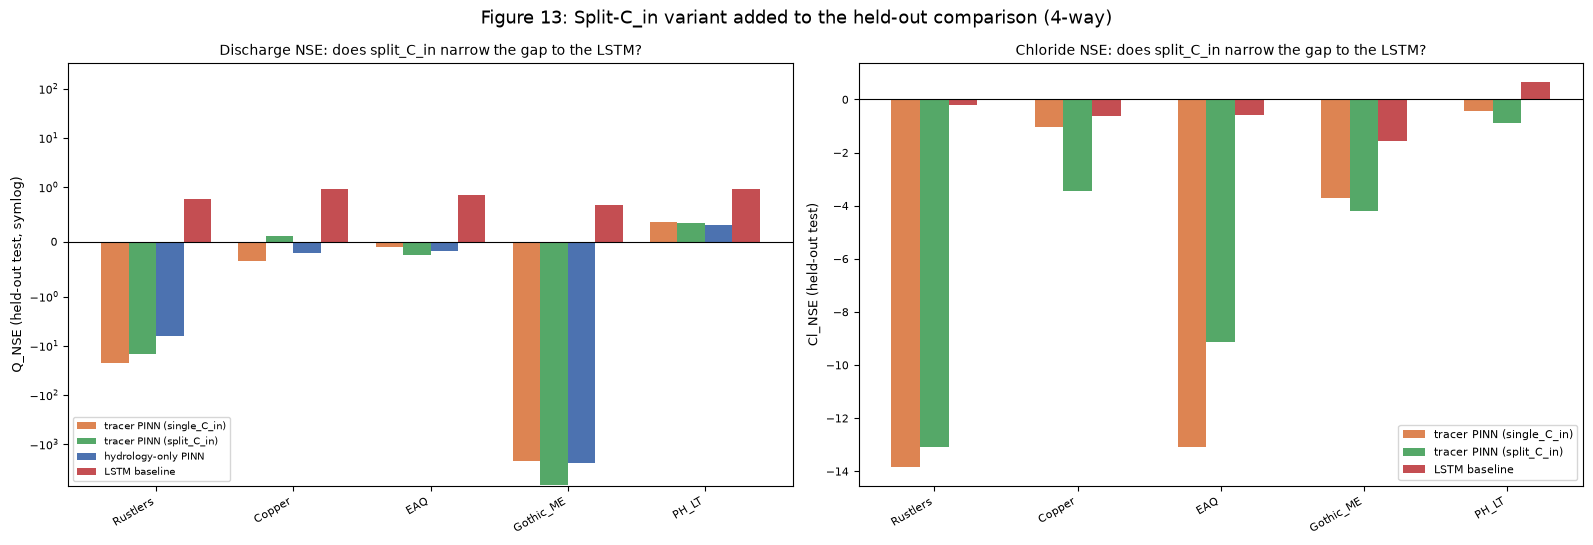

In [11]:
# results_comparative_tracer_split: the split-C_in tracer PINN retrained
# from scratch under the IDENTICAL held-out split as every other checkpoint
# in this comparison -- tests whether the more physically-motivated
# two-end-member formulation (C_in,fast / C_in,gw) narrows the gap to the
# LSTM at all, vs. just tracking single_C_in as it does in every
# non-held-out diagnostic elsewhere in this project.
TRACER_SPLIT_DIR = f"{PROJECT_ROOT}/results_comparative_tracer_split"
with open(f"{TRACER_SPLIT_DIR}/metrics.json") as f:
    split_info = json.load(f)

width = 0.2
q_single = [tracer_info["metrics"][b]["Q_NSE_test"] for b in ORDER]
q_split = [split_info["metrics"][b]["Q_NSE_test"] for b in ORDER]
cl_single = [tracer_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
cl_split = [split_info["metrics"][b]["Cl_NSE_test"] for b in ORDER]
# q_hydro, q_lstm, cl_lstm already loaded in the Figure 10 cell above.

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
ax = axes[0]
ax.bar(x - 1.5 * width, q_single, width, label="tracer PINN (single_C_in)", color=C["split"])
ax.bar(x - 0.5 * width, q_split, width, label="tracer PINN (split_C_in)", color=C["Cin_fast"])
ax.bar(x + 0.5 * width, q_hydro, width, label="hydrology-only PINN", color=C["single"])
ax.bar(x + 1.5 * width, q_lstm, width, label="LSTM baseline", color=C["highlight"])
ax.axhline(0, color="black", lw=0.8)
ax.set_yscale("symlog", linthresh=1.0)  # same Gothic_ME structural-issue rationale as Figures 10/12
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
ax.set_ylabel("Q_NSE (held-out test, symlog)")
ax.set_title("Discharge NSE: does split_C_in narrow the gap to the LSTM?")
ax.legend(fontsize=FONT["legend"] - 1, loc="lower left")

ax = axes[1]
ax.bar(x - width, cl_single, width, label="tracer PINN (single_C_in)", color=C["split"])
ax.bar(x, cl_split, width, label="tracer PINN (split_C_in)", color=C["Cin_fast"])
ax.bar(x + width, cl_lstm, width, label="LSTM baseline", color=C["highlight"])
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=30, ha="right")
ax.set_ylabel("Cl_NSE (held-out test)")
ax.set_title("Chloride NSE: does split_C_in narrow the gap to the LSTM?")
ax.legend(fontsize=FONT["legend"])

# Manuscript's reported result (Section 3.10): split narrows the gap at 2
# of 5 gauges per metric (Rustlers/Copper for discharge; Rustlers/EAQ for
# chloride) and does not narrow it at the rest. Gothic_ME's apparent
# discharge regression under the split variant is not distinguishable from
# this gauge's already-documented seed-to-seed volatility (Section 3.7) --
# a known caveat, not a new finding about split_C_in specifically.
fig.suptitle("Figure 13: Split-C_in variant added to the held-out comparison (4-way)")
fig.tight_layout()
plt.show()
